# Week 6 Lab: Uncertainty-Aware AI Systems

In [1]:
import sys
import os

# Print Python interpreter and version
print("Python Interpreter:", sys.executable)
print("Python Version:", sys.version)
print()

# Print Conda environment name
conda_env = os.environ.get("CONDA_DEFAULT_ENV")
print("Conda Environment:", conda_env if conda_env else "Not in a conda environment")
print()

# Check package versions
packages = ["numpy", "pandas", "matplotlib", "sklearn"]
print("Package Versions:")
print("-" * 40)

for package_name in packages:
    try:
        if package_name == "sklearn":
            import sklearn
            print(f"  {package_name}: {sklearn.__version__}")
        elif package_name == "numpy":
            import numpy
            print(f"  {package_name}: {numpy.__version__}")
        elif package_name == "pandas":
            import pandas
            print(f"  {package_name}: {pandas.__version__}")
        elif package_name == "matplotlib":
            import matplotlib
            print(f"  {package_name}: {matplotlib.__version__}")
    except ImportError:
        print(f"  {package_name}: ❌ NOT INSTALLED")
    except Exception as e:
        print(f"  {package_name}: ❌ ERROR - {e}")

Python Interpreter: c:\Users\charlesfoo\anaconda3\envs\trustworthy-ai\python.exe
Python Version: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:16:45) [MSC v.1942 64 bit (AMD64)]

Conda Environment: trustworthy-ai

Package Versions:
----------------------------------------
  numpy: 2.4.4
  pandas: 3.0.2
  matplotlib: 3.10.9
  sklearn: 1.8.0


In [3]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)

## Section 1: Load and Explore the Data

In [4]:
# Load the credit card fraud dataset
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:")
print(df.shape)
print("\n" + "="*60 + "\n")

print("First 5 Rows:")
print(df.head())
print("\n" + "="*60 + "\n")

print("Class Distribution:")
print("0 = Legitimate, 1 = Fraud")
print(df["Class"].value_counts())
print()

# Calculate fraud percentage
fraud_count = df["Class"].sum()
total_count = len(df)
fraud_percentage = (fraud_count / total_count) * 100

print(f"Fraud Percentage: {fraud_percentage:.4f}%")
print()
print(f"Observation: Only {fraud_percentage:.4f}% of transactions are fraudulent, indicating a severe class imbalance.")

Dataset Shape:
(284807, 31)


First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0

## Section 2: Preprocess and Train/Test Split

In [7]:
# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# Stratified train/test split to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train/Test Split Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("\n" + "="*60 + "\n")

# Verify stratification worked
train_fraud_count = y_train.sum()
train_total = len(y_train)
train_fraud_pct = (train_fraud_count / train_total) * 100

test_fraud_count = y_test.sum()
test_total = len(y_test)
test_fraud_pct = (test_fraud_count / test_total) * 100

print("Training Set Class Distribution:")
print(f"  Total samples: {train_total}")
print(f"  Fraud count: {train_fraud_count}")
print(f"  Fraud percentage: {train_fraud_pct:.4f}%")
print()

print("Test Set Class Distribution:")
print(f"  Total samples: {test_total}")
print(f"  Fraud count: {test_fraud_count}")
print(f"  Fraud percentage: {test_fraud_pct:.4f}%")
print()

print("✓ Stratification preserved the fraud ratio in both sets.")

Train/Test Split Shapes:
X_train: (227845, 30)
X_test: (56962, 30)


Training Set Class Distribution:
  Total samples: 227845
  Fraud count: 394
  Fraud percentage: 0.1729%

Test Set Class Distribution:
  Total samples: 56962
  Fraud count: 98
  Fraud percentage: 0.1720%

✓ Stratification preserved the fraud ratio in both sets.


In [6]:
# Scale only Time and Amount (V1-V28 are already PCA-scaled)
scaler = StandardScaler()

# Fit scaler ONLY on training data
scaler.fit(X_train[["Time", "Amount"]])

# Create copies and transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.transform(X_train[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

# Keep scaler in memory for later use with out-of-distribution samples
print("Feature Scaling Complete")
print("="*60)
print()

print("Scaled Time and Amount Statistics (Training Set):")
print(X_train_scaled[["Time", "Amount"]].describe())
print()
print("="*60)
print()

print("First 5 rows of scaled training data (verify V1-V28 unchanged):")
print(X_train_scaled.head())

Feature Scaling Complete

Scaled Time and Amount Statistics (Training Set):
               Time        Amount
count  2.278450e+05  2.278450e+05
mean  -1.409578e-16  3.742243e-17
std    1.000002e+00  1.000002e+00
min   -1.998073e+00 -3.516894e-01
25%   -8.561495e-01 -3.291944e-01
50%   -2.122647e-01 -2.639429e-01
75%    9.366285e-01 -4.262209e-02
max    1.640549e+00  1.021170e+02


First 5 rows of scaled training data (verify V1-V28 unchanged):
            Time        V1        V2        V3        V4        V5        V6  \
265518  1.411588  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
180305  0.623141  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
42664  -1.130680 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
198723  0.794699  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
82325  -0.748102 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

              V7        V8        V9  ...       V20       V21       V22

## Section 3: Baseline Model and Clean Accuracy

In [9]:
# Train baseline logistic regression model
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Compute clean accuracy
clean_accuracy = accuracy_score(y_test, y_pred)

print("Baseline Model Performance on Clean Test Data:")
print("="*60)
print(f"Clean Accuracy: {clean_accuracy * 100:.4f}%")
print()
print(f"Observation: The accuracy is very high ({clean_accuracy * 100:.4f}%), but this may be misleading due to the severe class imbalance.")

Baseline Model Performance on Clean Test Data:
Clean Accuracy: 99.9157%

Observation: The accuracy is very high (99.9157%), but this may be misleading due to the severe class imbalance.


## Section 4: Confidence Scores

**Definition:** Confidence is the highest class probability output by the model:  
**confidence = max(P(legitimate), P(fraud))**

A high confidence indicates the model is certain about its prediction, while low confidence suggests uncertainty.

In [10]:
# Get class probabilities: column 0 = P(legit), column 1 = P(fraud)
proba = model.predict_proba(X_test_scaled)

# Compute confidence as the row-wise maximum
confidence = np.max(proba, axis=1)

print("Confidence Score Statistics:")
print("="*60)
print(f"Mean:   {np.mean(confidence):.4f}")
print(f"Median: {np.median(confidence):.4f}")
print(f"Min:    {np.min(confidence):.4f}")
print(f"Max:    {np.max(confidence):.4f}")
print()
print("="*60)
print()

# Compute percentage of predictions at various confidence thresholds
pct_90 = (confidence >= 0.90).sum() / len(confidence) * 100
pct_99 = (confidence >= 0.99).sum() / len(confidence) * 100
pct_999 = (confidence >= 0.999).sum() / len(confidence) * 100

print("Percentage of predictions with high confidence:")
print(f"  Confidence >= 0.90:  {pct_90:.2f}%")
print(f"  Confidence >= 0.99:  {pct_99:.2f}%")
print(f"  Confidence >= 0.999: {pct_999:.2f}%")

Confidence Score Statistics:
Mean:   0.9993
Median: 0.9998
Min:    0.5109
Max:    1.0000


Percentage of predictions with high confidence:
  Confidence >= 0.90:  99.92%
  Confidence >= 0.99:  99.67%
  Confidence >= 0.999: 91.05%


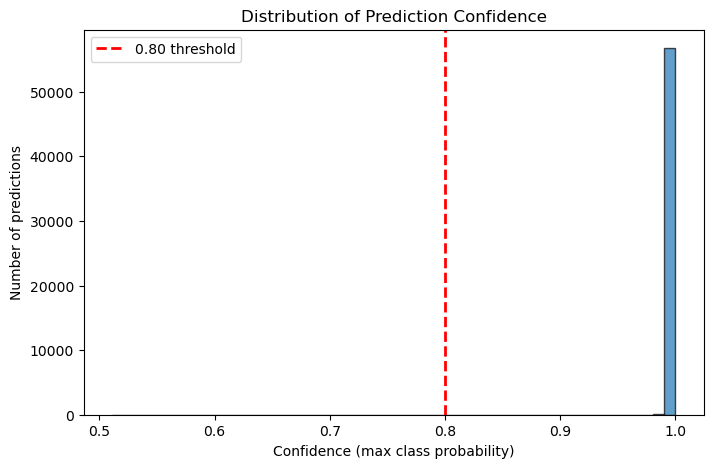

In [11]:
# Plot histogram of confidence scores
plt.hist(confidence, bins=50, edgecolor='black', alpha=0.7)
plt.title("Distribution of Prediction Confidence")
plt.xlabel("Confidence (max class probability)")
plt.ylabel("Number of predictions")
plt.axvline(x=0.80, color='red', linestyle='--', linewidth=2, label='0.80 threshold')
plt.legend()
plt.show()

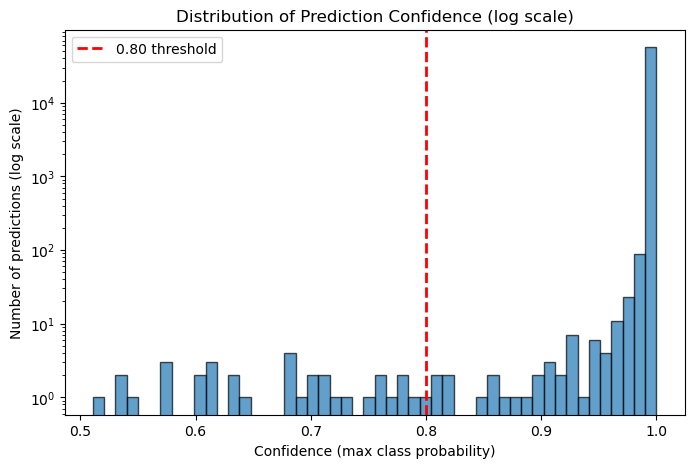

In [12]:
# Plot histogram with logarithmic y-axis to see low-confidence predictions
plt.hist(confidence, bins=50, edgecolor='black', alpha=0.7)
plt.yscale("log")
plt.title("Distribution of Prediction Confidence (log scale)")
plt.xlabel("Confidence (max class probability)")
plt.ylabel("Number of predictions (log scale)")
plt.axvline(x=0.80, color='red', linestyle='--', linewidth=2, label='0.80 threshold')
plt.legend()
plt.show()

## Section 5: Out-of-Distribution (OOD) Samples

We take real test transactions that the model is confident about, then perturb them far outside the training distribution by dramatically increasing ONLY the transaction Amount (multiplied by 1000). Per the lab requirement to apply a single perturbation, the Time feature is left unchanged.

**Key point:** We reuse the SAME scaler fitted in Section 2 so the perturbed inputs are transformed identically to how the training data was processed.

In [27]:
# Select 5 legitimate test transactions (Class == 0) from original unscaled X_test
ood_base = X_test[y_test == 0].head(5).copy()

print("Original 5 Legitimate Test Transactions:")
print("="*60)
print(ood_base[["Time", "Amount"]])
print()

# Create perturbed copy with extreme out-of-distribution values
# ONLY perturb Amount (multiply by 1000), leave Time UNCHANGED
ood_perturbed = ood_base.copy()
ood_perturbed["Amount"] = ood_perturbed["Amount"] * 1000  # Dramatic increase

print("Perturbed Transactions (OOD - Amount x1000):")
print("="*60)
print(ood_perturbed[["Time", "Amount"]])
print()

# Scale both base and perturbed using the EXISTING scaler from Section 2
ood_base_scaled = ood_base.copy()
ood_perturbed_scaled = ood_perturbed.copy()

ood_base_scaled[["Time", "Amount"]] = scaler.transform(ood_base[["Time", "Amount"]])
ood_perturbed_scaled[["Time", "Amount"]] = scaler.transform(ood_perturbed[["Time", "Amount"]])

# Get predictions and probabilities for both
pred_base = model.predict(ood_base_scaled)
proba_base = model.predict_proba(ood_base_scaled)
conf_base = np.max(proba_base, axis=1)

pred_perturbed = model.predict(ood_perturbed_scaled)
proba_perturbed = model.predict_proba(ood_perturbed_scaled)
conf_perturbed = np.max(proba_perturbed, axis=1)

# Build comparison DataFrame
comparison = pd.DataFrame({
    "Sample": range(1, 6),
    "Original_Pred": pred_base,
    "Original_Conf": conf_base,
    "Perturbed_Pred": pred_perturbed,
    "Perturbed_Conf": conf_perturbed
})

print("Comparison: Base vs. Perturbed Predictions")
print("="*60)
print(comparison.to_string(index=False))
print()
print("Note: Original predictions should be 0 (legitimate) with high confidence.")
print("Check whether perturbed predictions maintain high confidence despite OOD inputs.")

Original 5 Legitimate Test Transactions:
            Time  Amount
263020  160760.0   23.00
11378    19847.0   11.85
147283   88326.0   76.07
219439  141734.0    0.99
36939    38741.0    1.50

Perturbed Transactions (OOD - Amount x1000):
            Time   Amount
263020  160760.0  23000.0
11378    19847.0  11850.0
147283   88326.0  76070.0
219439  141734.0    990.0
36939    38741.0   1500.0

Comparison: Base vs. Perturbed Predictions
 Sample  Original_Pred  Original_Conf  Perturbed_Pred  Perturbed_Conf
      1              0       0.999910               0        0.640863
      2              0       0.999969               0        0.997212
      3              0       0.999992               1        1.000000
      4              0       0.999870               0        0.999811
      5              0       0.991862               0        0.985707

Note: Original predictions should be 0 (legitimate) with high confidence.
Check whether perturbed predictions maintain high confidence despite

In [14]:
# Inspect logistic regression coefficients to explain OOD behavior
feature_names = X_train_scaled.columns.tolist()
coefficients = model.coef_[0]

print("Logistic Regression Model Inspection:")
print("="*60)
print()

# Print Time and Amount coefficients specifically
time_idx = feature_names.index("Time")
amount_idx = feature_names.index("Amount")

print("Key Feature Coefficients:")
print(f"  Time coefficient:   {coefficients[time_idx]:.6f}")
print(f"  Amount coefficient: {coefficients[amount_idx]:.6f}")
print()

# Print intercept
print(f"Model Intercept: {model.intercept_[0]:.6f}")
print()
print("="*60)
print()

# Sort features by absolute coefficient value
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
})
coef_df_sorted = coef_df.sort_values("Abs_Coefficient", ascending=False)

print("Top 8 Features by Absolute Coefficient Value:")
print(coef_df_sorted.head(8)[["Feature", "Coefficient"]].to_string(index=False))
print()
print("Interpretation: Large positive coefficients increase fraud probability.")
print("Amount's coefficient helps explain why large perturbed amounts affect predictions.")

Logistic Regression Model Inspection:

Key Feature Coefficients:
  Time coefficient:   0.015154
  Amount coefficient: 0.095290

Model Intercept: -8.771218


Top 8 Features by Absolute Coefficient Value:
Feature  Coefficient
     V4     0.702851
    V10    -0.671770
    V14    -0.654406
    V22     0.525087
    V13    -0.519414
    V27    -0.421585
    V16    -0.392870
    V21     0.326014

Interpretation: Large positive coefficients increase fraud probability.
Amount's coefficient helps explain why large perturbed amounts affect predictions.


## Figure for OOD Perturbation Comparison

Figure saved as: ood_comparison.png



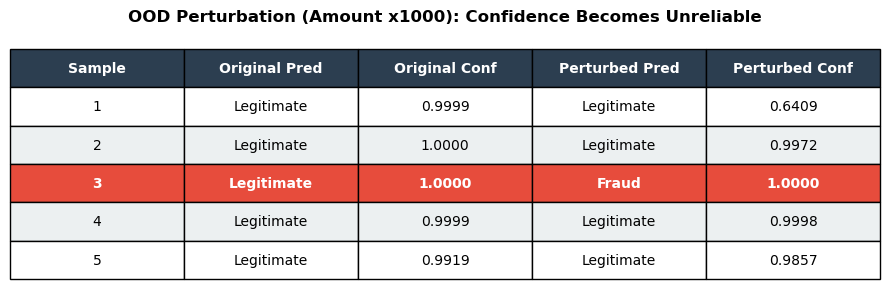

In [26]:
# Reuse the comparison DataFrame from Section 5 (already in memory)
# It has: Sample, Original_Pred, Original_Conf, Perturbed_Pred, Perturbed_Conf

# Create display DataFrame with formatted values
pred_map = {0: "Legitimate", 1: "Fraud"}

display_ood = pd.DataFrame({
    "Sample": comparison["Sample"],
    "Original Pred": comparison["Original_Pred"].map(pred_map),
    "Original Conf": comparison["Original_Conf"].apply(lambda x: f"{x:.4f}"),
    "Perturbed Pred": comparison["Perturbed_Pred"].map(pred_map),
    "Perturbed Conf": comparison["Perturbed_Conf"].apply(lambda x: f"{x:.4f}")
})

# Create matplotlib figure
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')  # Hide axes

# Create table from display DataFrame
table_data = [display_ood.columns.tolist()] + display_ood.values.tolist()
table = ax.table(cellText=table_data, cellLoc='center', loc='center', 
                 bbox=[0, 0, 1, 1])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)  # Scale rows for readability

# Style header row (row 0)
for j in range(len(display_ood.columns)):
    cell = table[(0, j)]
    cell.set_facecolor('#2C3E50')  # Dark blue-gray
    cell.set_text_props(weight='bold', color='white')

# Apply alternating row shading and highlight row where prediction flips
for i in range(1, len(table_data)):
    sample_idx = i - 1  # Map to display_ood index
    orig_pred = display_ood.iloc[sample_idx]["Original Pred"]
    pert_pred = display_ood.iloc[sample_idx]["Perturbed Pred"]
    
    # Check if prediction flipped
    prediction_flipped = (orig_pred != pert_pred)
    
    for j in range(len(display_ood.columns)):
        cell = table[(i, j)]
        
        if prediction_flipped:
            # Highlight rows where prediction changed (Sample 3)
            cell.set_facecolor('#E74C3C')  # Red highlight
            cell.set_text_props(weight='bold', color='white')
        elif i % 2 == 0:
            cell.set_facecolor('#ECF0F1')  # Light gray for even rows
        else:
            cell.set_facecolor('white')  # White for odd rows

# Add title above the table
plt.title("OOD Perturbation (Amount x1000): Confidence Becomes Unreliable",
          fontsize=12, weight='bold', pad=20)

plt.tight_layout()

# Save high-resolution figure for slides
plt.savefig("ood_comparison.png", dpi=200, bbox_inches="tight")
print("Figure saved as: ood_comparison.png")
print()

plt.show()

## Section 6: Silent Failure Analysis (High-Confidence Errors)

**Silent Failure:** A prediction that is WRONG but made with HIGH confidence.

The most dangerous case in fraud detection is an actual fraud (Class=1) that the model confidently labels as legitimate (predicts 0) — a **high-confidence false negative**. These transactions pass through without scrutiny, causing real financial loss.

In [15]:
# Build results DataFrame aligned to test set
results_df = pd.DataFrame({
    "true_label": y_test.values,
    "pred_label": y_pred,
    "confidence": confidence,
    "prob_fraud": proba[:, 1]
})

# Identify all misclassified cases
misclassified = results_df[results_df["true_label"] != results_df["pred_label"]]

print("Silent Failure Analysis:")
print("="*60)
print()

# High-confidence false negatives: actual fraud (1) predicted as legit (0) with high confidence
high_conf_fn = misclassified[
    (misclassified["true_label"] == 1) & 
    (misclassified["pred_label"] == 0) & 
    (misclassified["confidence"] >= 0.99)
]

# High-confidence false positives: actual legit (0) predicted as fraud (1) with high confidence
high_conf_fp = misclassified[
    (misclassified["true_label"] == 0) & 
    (misclassified["pred_label"] == 1) & 
    (misclassified["confidence"] >= 0.99)
]

print(f"High-Confidence False Negatives (missed frauds): {len(high_conf_fn)}")
print(f"High-Confidence False Positives (false alarms): {len(high_conf_fp)}")
print()
print("="*60)
print()

if len(high_conf_fn) > 0:
    print("High-Confidence False Negatives (Frauds Confidently Missed):")
    print("Sorted by confidence (most confident mistakes first)")
    print()
    high_conf_fn_sorted = high_conf_fn.sort_values("confidence", ascending=False)
    print(high_conf_fn_sorted[["true_label", "pred_label", "confidence", "prob_fraud"]].to_string(index=True))
    print()
else:
    print("No high-confidence false negatives found (good news!)")
    print()

print("="*60)
print()

# Summary
total_frauds_in_test = (y_test == 1).sum()
print(f"SUMMARY: {len(high_conf_fn)} actual frauds were confidently misclassified as legitimate")
print(f"         out of {total_frauds_in_test} total fraud cases in the test set.")
print(f"         Silent failure rate: {len(high_conf_fn) / total_frauds_in_test * 100:.2f}%")

Silent Failure Analysis:

High-Confidence False Negatives (missed frauds): 11
High-Confidence False Positives (false alarms): 10


High-Confidence False Negatives (Frauds Confidently Missed):
Sorted by confidence (most confident mistakes first)

       true_label  pred_label  confidence  prob_fraud
34124           1           0    0.999957    0.000043
24869           1           0    0.999911    0.000089
20992           1           0    0.999883    0.000117
55247           1           0    0.999853    0.000147
17046           1           0    0.999757    0.000243
54191           1           0    0.999732    0.000268
31208           1           0    0.999730    0.000270
54752           1           0    0.999668    0.000332
28390           1           0    0.999468    0.000532
56143           1           0    0.998815    0.001185
24570           1           0    0.998380    0.001620


SUMMARY: 11 actual frauds were confidently misclassified as legitimate
         out of 98 total fraud ca

## Figure for High-Confidence Silent Failures

Figure saved as: slide8_silent_failures.png



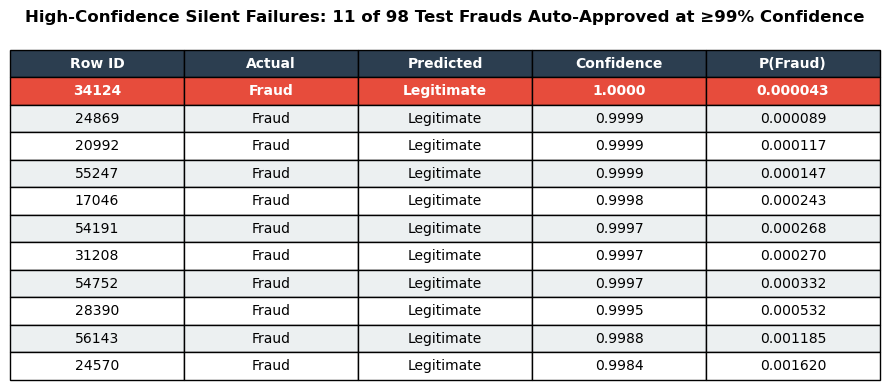

In [23]:
# Select high-confidence false negatives from results_df
# (actual fraud predicted as legitimate with confidence >= 0.99)
hc_fn = results_df[
    (results_df["true_label"] == 1) & 
    (results_df["pred_label"] == 0) & 
    (results_df["confidence"] >= 0.99)
].copy()

# Sort by confidence descending (worst cases first)
hc_fn_sorted = hc_fn.sort_values("confidence", ascending=False)

# Build display DataFrame with renamed columns for readability
display_df = pd.DataFrame({
    "Row ID": hc_fn_sorted.index,
    "Actual": ["Fraud"] * len(hc_fn_sorted),
    "Predicted": ["Legitimate"] * len(hc_fn_sorted),
    "Confidence": hc_fn_sorted["confidence"].apply(lambda x: f"{x:.4f}"),
    "P(Fraud)": hc_fn_sorted["prob_fraud"].apply(lambda x: f"{x:.6f}")
})

# Reset index for clean table display
display_df = display_df.reset_index(drop=True)

# Create matplotlib figure
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')  # Hide axes

# Create table from display DataFrame
table_data = [display_df.columns.tolist()] + display_df.values.tolist()
table = ax.table(cellText=table_data, cellLoc='center', loc='center', 
                 bbox=[0, 0, 1, 1])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)  # Scale rows for readability

# Style header row (row 0)
for j in range(len(display_df.columns)):
    cell = table[(0, j)]
    cell.set_facecolor('#2C3E50')  # Dark blue-gray
    cell.set_text_props(weight='bold', color='white')

# Apply alternating row shading and highlight worst case (row 1 = first data row)
for i in range(1, len(table_data)):
    for j in range(len(display_df.columns)):
        cell = table[(i, j)]
        
        if i == 1:  # First data row = worst case (highest confidence)
            cell.set_facecolor('#E74C3C')  # Red highlight for worst case
            cell.set_text_props(weight='bold', color='white')
        elif i % 2 == 0:
            cell.set_facecolor('#ECF0F1')  # Light gray for even rows
        else:
            cell.set_facecolor('white')  # White for odd rows

# Add title above the table
plt.title("High-Confidence Silent Failures: 11 of 98 Test Frauds Auto-Approved at ≥99% Confidence",
          fontsize=12, weight='bold', pad=20)

plt.tight_layout()

# Save high-resolution figure for slides
plt.savefig("slide8_silent_failures.png", dpi=200, bbox_inches="tight")
print("Figure saved as: slide8_silent_failures.png")
print()

plt.show()

## Section 7: Confidence Threshold and Human-in-the-Loop Routing

**Strategy:** Predictions with confidence ≥ threshold are auto-processed; predictions below the threshold are escalated to a human reviewer.

**Threshold Selection Rationale:**

The scaffold's 80% threshold is explicitly only an example ("come up with your own threshold"). We select thresholds based on THIS model's actual confidence distribution rather than a textbook default.

From Section 4, we saw that:
- Over 99% of predictions exceed 0.99 confidence
- 91% of predictions exceed 0.999 confidence
- The confidence distribution is saturated near 1.0

A conventional threshold like 0.80 sits far to the LEFT of almost all the data and would escalate almost nothing on this overconfident model.

**Five Thresholds to Demonstrate the Trade-off:**

1. **0.80** = Low anchor; a normal-looking threshold, included to demonstrate it escalates almost nothing
2. **0.90** = Still left of the bulk; minimal escalation
3. **0.99** = Entering the dense region; escalation becomes visible
4. **0.999** = Inside the dense region; escalation climbs
5. **0.9999** = Deep where most predictions sit; escalates the most, yet still cannot catch all high-confidence silent failures from Section 6

**Goal:** Show how the escalation dial moves from "does nothing" (0.80) to "does something but still misses dangerous cases" (0.9999).

In [16]:
# Define five thresholds positioned relative to the model's actual confidence distribution
thresholds = [
    0.80,    # Low anchor: normal-looking threshold, but escalates almost nothing here
    0.90,    # Minimal escalation: still left of the bulk of predictions
    0.99,    # Entering data: escalation becomes visible
    0.999,   # Inside data: escalation climbs significantly
    0.9999   # Deep in data: escalates the most, but still misses high-confidence errors
]

# Use the results DataFrame from Section 6
# Columns: true_label, pred_label, confidence, prob_fraud
results = []

total_test_cases = len(results_df)
total_frauds = (results_df["true_label"] == 1).sum()

for T in thresholds:
    # Route each prediction: AUTO if confident enough, otherwise ESCALATE to human
    auto = results_df[results_df["confidence"] >= T]
    escalate = results_df[results_df["confidence"] < T]
    
    # Volume metrics: how much is automated vs sent to humans
    auto_count = len(auto)
    escalate_count = len(escalate)
    automation_rate = (auto_count / total_test_cases) * 100
    escalation_rate = (escalate_count / total_test_cases) * 100
    
    # Error metrics WITHIN the auto group only — mistakes that slip through with no human review
    # Auto_FalseNeg: frauds (true=1) auto-approved as legitimate (pred=0) = silent failures
    auto_false_neg = len(auto[(auto["true_label"] == 1) & (auto["pred_label"] == 0)])
    
    # Auto_FalsePos: legitimate (true=0) auto-flagged as fraud (pred=1) = false alarms
    auto_false_pos = len(auto[(auto["true_label"] == 0) & (auto["pred_label"] == 1)])
    
    # Fraud routing: of the 98 test frauds, how many reach a human vs stay automated
    frauds_escalated = len(escalate[escalate["true_label"] == 1])
    frauds_in_auto = len(auto[auto["true_label"] == 1])
    
    # Collect metrics for this threshold
    results.append({
        "Threshold": T,
        "Auto_Count": auto_count,
        "Escalate_Count": escalate_count,
        "Automation_Rate_%": automation_rate,
        "Escalation_Rate_%": escalation_rate,
        "Auto_FalseNeg": auto_false_neg,
        "Auto_FalsePos": auto_false_pos,
        "Frauds_Escalated": frauds_escalated,
        "Frauds_in_Auto": frauds_in_auto
    })

# Build summary DataFrame, one row per threshold
summary_df = pd.DataFrame(results)

# Round percentage columns to 2 decimal places
summary_df["Automation_Rate_%"] = summary_df["Automation_Rate_%"].round(2)
summary_df["Escalation_Rate_%"] = summary_df["Escalation_Rate_%"].round(2)

print("Human-in-the-Loop Routing Analysis")
print("="*80)
print(f"Total test cases: {total_test_cases}")
print(f"Total frauds in test set: {total_frauds}")
print()
print("Summary: Impact of Different Confidence Thresholds")
print("="*80)
print(summary_df.to_string(index=False))
print()
print("Key Observations:")
print("- Auto_FalseNeg = Silent failures (frauds confidently auto-approved)")
print("- Frauds_Escalated = How many of the 98 frauds get human review")
print("- At 0.80-0.90: Nearly all predictions automated; almost no fraud protection")
print("- At 0.9999: More escalation, but still misses high-confidence false negatives")

Human-in-the-Loop Routing Analysis
Total test cases: 56962
Total frauds in test set: 98

Summary: Impact of Different Confidence Thresholds
 Threshold  Auto_Count  Escalate_Count  Automation_Rate_%  Escalation_Rate_%  Auto_FalseNeg  Auto_FalsePos  Frauds_Escalated  Frauds_in_Auto
    0.8000       56928              34              99.94               0.06             25             11                19              79
    0.9000       56917              45              99.92               0.08             23             11                24              74
    0.9900       56776             186              99.67               0.33             11             10                46              52
    0.9990       51866            5096              91.05               8.95              9              4                60              38
    0.9999       20428           36534              35.86              64.14              2              2                75              23

Key Observati

## Figure for Confidence Threshold Routing Summary

Figure saved as: threshold_routing.png



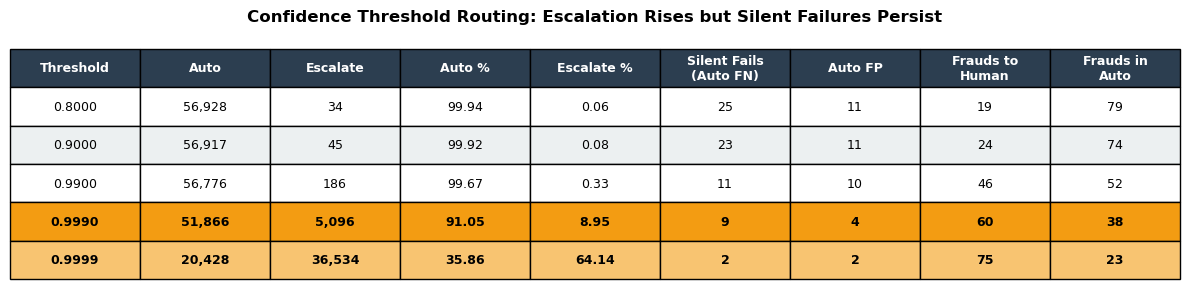

In [28]:
# Use the existing summary_df from Section 7 and create a display version
# with shorter, readable column headers

display_threshold = pd.DataFrame({
    "Threshold": summary_df["Threshold"].apply(lambda x: f"{x:.4f}"),
    "Auto": summary_df["Auto_Count"].apply(lambda x: f"{x:,}"),
    "Escalate": summary_df["Escalate_Count"].apply(lambda x: f"{x:,}"),
    "Auto %": summary_df["Automation_Rate_%"].apply(lambda x: f"{x:.2f}"),
    "Escalate %": summary_df["Escalation_Rate_%"].apply(lambda x: f"{x:.2f}"),
    "Silent Fails\n(Auto FN)": summary_df["Auto_FalseNeg"],
    "Auto FP": summary_df["Auto_FalsePos"],
    "Frauds to\nHuman": summary_df["Frauds_Escalated"],
    "Frauds in\nAuto": summary_df["Frauds_in_Auto"]
})

# Create matplotlib figure (wider to accommodate more columns)
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')  # Hide axes

# Create table from display DataFrame
table_data = [display_threshold.columns.tolist()] + display_threshold.values.tolist()
table = ax.table(cellText=table_data, cellLoc='center', loc='center', 
                 bbox=[0, 0, 1, 1])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.0)  # Scale rows for readability

# Style header row (row 0)
for j in range(len(display_threshold.columns)):
    cell = table[(0, j)]
    cell.set_facecolor('#2C3E50')  # Dark blue-gray
    cell.set_text_props(weight='bold', color='white')

# Apply row-specific styling
for i in range(1, len(table_data)):
    threshold_val = summary_df.iloc[i-1]["Threshold"]
    
    for j in range(len(display_threshold.columns)):
        cell = table[(i, j)]
        
        # Highlight 0.999 row (recommended operating point) in gold
        if threshold_val == 0.999:
            cell.set_facecolor('#F39C12')  # Orange/gold highlight
            cell.set_text_props(weight='bold')
        # Highlight 0.9999 row (extreme trade-off) in lighter orange
        elif threshold_val == 0.9999:
            cell.set_facecolor('#F8C471')  # Light orange
            cell.set_text_props(weight='bold')
        # Regular alternating shading for other rows
        elif i % 2 == 0:
            cell.set_facecolor('#ECF0F1')  # Light gray for even rows
        else:
            cell.set_facecolor('white')  # White for odd rows

# Add title above the table
plt.title("Confidence Threshold Routing: Escalation Rises but Silent Failures Persist",
          fontsize=12, weight='bold', pad=20)

plt.tight_layout()

# Save high-resolution figure for slides
plt.savefig("threshold_routing.png", dpi=200, bbox_inches="tight")
print("Figure saved as: threshold_routing.png")
print()

plt.show()

## Section 8: Trade-offs Analysis

The baseline clean accuracy of 99.92% (Section 3) is misleading under severe class imbalance. This section exposes the real error profile with a confusion matrix and consolidates the threshold trade-offs to reveal what the model is actually learning.

In [17]:
# Compute confusion matrix on baseline predictions (default 0.5 threshold)
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (Baseline Model):")
print("="*60)
print("Rows = Actual, Columns = Predicted")
print()
print("                 Predicted Legitimate  Predicted Fraud")
print(f"Actual Legitimate        {cm[0,0]:6d}              {cm[0,1]:6d}")
print(f"Actual Fraud             {cm[1,0]:6d}              {cm[1,1]:6d}")
print()

# Explicitly label the four counts
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print("Breakdown:")
print(f"  True Negatives (TN):  {tn:6d}  (legitimate correctly classified)")
print(f"  False Positives (FP): {fp:6d}  (legitimate incorrectly flagged as fraud)")
print(f"  False Negatives (FN): {fn:6d}  (fraud incorrectly classified as legitimate)")
print(f"  True Positives (TP):  {tp:6d}  (fraud correctly detected)")
print()
print("="*60)
print()

# Print classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))
print("="*60)
print()

# Compare to naive baseline
total_test = len(y_test)
num_legit = (y_test == 0).sum()
naive_accuracy = (num_legit / total_test) * 100
model_accuracy = accuracy_score(y_test, y_pred) * 100

print("Comparison to Naive Baseline:")
print(f"  Naive 'always predict legitimate' accuracy: {naive_accuracy:.4f}%")
print(f"  Our model's accuracy:                       {model_accuracy:.4f}%")
print(f"  Improvement over naive baseline:            {model_accuracy - naive_accuracy:.4f}%")
print()
print("Interpretation: The high accuracy is mostly due to correctly predicting")
print("the abundant legitimate class. The real test is fraud detection (recall).")

Confusion Matrix (Baseline Model):
Rows = Actual, Columns = Predicted

                 Predicted Legitimate  Predicted Fraud
Actual Legitimate         56851                  13
Actual Fraud                 35                  63

Breakdown:
  True Negatives (TN):   56851  (legitimate correctly classified)
  False Positives (FP):     13  (legitimate incorrectly flagged as fraud)
  False Negatives (FN):     35  (fraud incorrectly classified as legitimate)
  True Positives (TP):      63  (fraud correctly detected)


Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Comparison to Naive Baseline:
  Naive 'always predict legitimate' accuracy: 99.8280%
  Our model's accuracy:                     

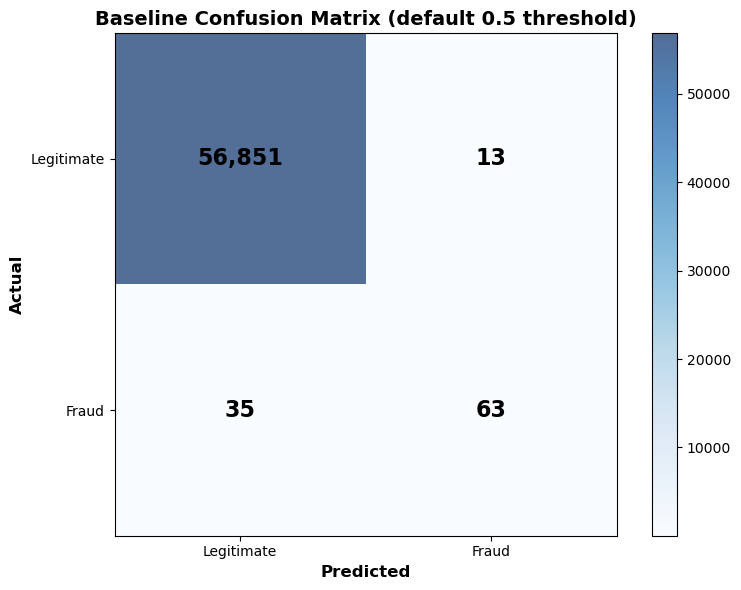

In [18]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

# Display confusion matrix as heatmap
im = ax.imshow(cm, cmap='Blues', alpha=0.7)

# Add colorbar
plt.colorbar(im, ax=ax)

# Annotate each cell with its count
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, f'{cm[i, j]:,}',
                      ha="center", va="center", color="black", fontsize=16, weight='bold')

# Set labels and title
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_yticklabels(['Legitimate', 'Fraud'])
ax.set_xlabel('Predicted', fontsize=12, weight='bold')
ax.set_ylabel('Actual', fontsize=12, weight='bold')
ax.set_title('Baseline Confusion Matrix (default 0.5 threshold)', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

## Figure for Accuracy vs Naive Baseline

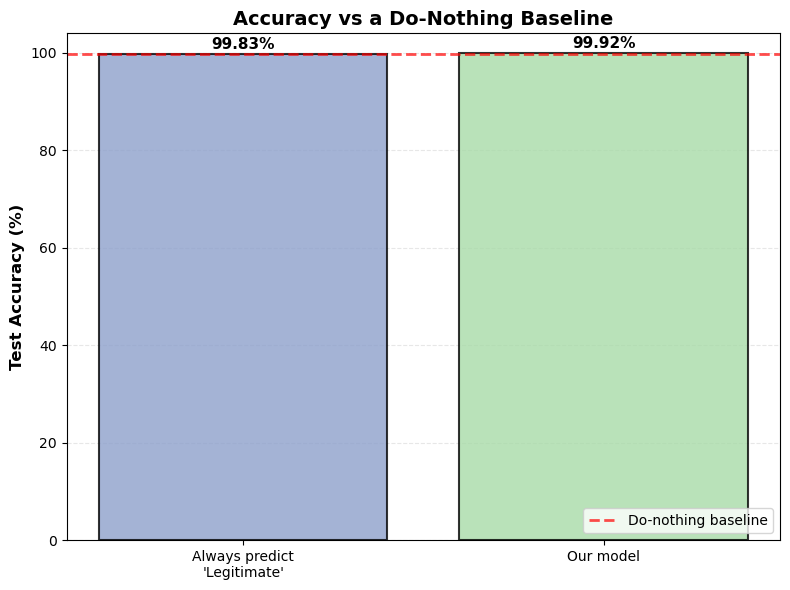

In [22]:
# Calculate accuracies for comparison
naive_acc = (y_test == 0).sum() / len(y_test) * 100  # "always predict legitimate"
model_acc = accuracy_score(y_test, y_pred) * 100

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 6))

labels = ["Always predict\n'Legitimate'", "Our model"]
heights = [naive_acc, model_acc]
colors = ['#8DA0CB', '#A8DBA8']  # Muted blue and muted green

bars = ax.bar(labels, heights, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# CRITICAL: Set y-axis limits to show bars on true scale with room for annotations
plt.ylim(0, 104)

# Annotate each bar with exact value
for i, (bar, height) in enumerate(zip(bars, heights)):
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.4, 
            f'{height:.2f}%', 
            ha='center', va='bottom', fontsize=11, weight='bold')

# Add horizontal dashed line at naive baseline height
ax.axhline(y=naive_acc, color='red', linestyle='--', linewidth=2, 
           label='Do-nothing baseline', alpha=0.7)

# Labels and title
ax.set_ylabel('Test Accuracy (%)', fontsize=12, weight='bold')
ax.set_title('Accuracy vs a Do-Nothing Baseline', fontsize=14, weight='bold')

# Add light horizontal gridlines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Legend
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()